In [1]:
import pandas as pd
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def busqueda_incremental(f,a,b,h=1e-6):
    x0 = a
    x1 = a + h
    n = 0
    while f(x0)*f(x1)>0:
        x0 = x1
        x1 = x0 + h
        if x1>b:
            return('No hay raíz')
            break
        n += 1
    return [x1,n]

In [3]:
def biseccion(f,x0,x1,h=1e-6): #h el mínimo tamaño de paso
    x2 = (x0+x1)/2
    n = 0
    dx = abs(x0-x1)
    while dx>=h:
        if f(x0)*f(x2)<0:
            x1 = x2
            x2 = (x0+x1)/2
        elif f(x2)*f(x1)<0:
            x0 = x2
            x2 = (x0+x1)/2
        else:
            dx = h/2 ##break
            print('El intervalo no tiene raíz')
        dx = abs(x1-x0)
        n = n+1
    return [x1,n]

In [4]:
def newton_rhapson(f,df,x0,h=1e-6):
    dx = 2*h #intervalo para poder entrar al while,, dps lo vamos a redefinir
    n = 0
    while dx>h:
        x1 = x0 - (f(x0)/df(x0))
        dx = abs(x0-x1)
        x0 = x1
        n = n + 1
    return [x0,n]

In [5]:
def secante(f,x0,x1,h=1e-6):
    dx = 2*h
    n = 0
    while dx>h:
        x2 = x0 - ((x1-x0)/(f(x1)-f(x0)))*f(x0)
        dx = abs(x0-x1)
        x0 = x1
        x1 = x2
        n += 1
    return [x2,n]

In [6]:
def ridders(f,x0,x1,h=1e-6):
    dx = abs(x0-x1)
    n = 0
    #Comenzamos con la parte de bisección
    x2 = (x0+x1)/2
    while dx>=h:
        if f(x0)*f(x2)<0:
            x1 = x2
            x2 = (x0+x1)/2
            #Ya determinamos el intervalo con el que trabajaremos para la siguiente parte. Ahora aplicamos el método de la secante.
            if f(x0)>f(x1): #caso decreciente
                x3 = x2 + (x2-x0)*(f(x2)/(sqrt(f(x2)**2-f(x0)*f(x1))))
            elif f(x0)<f(x1): #caso creciente
                x3 = x2 - (x2-x0)*(f(x2)/(sqrt(f(x2)**2-f(x0)*f(x1))))
                
        elif f(x2)*f(x1)<0:
            x0 = x2
            x2 = (x0+x1)/2
            #Ya determinamos el intervalo con el que trabajaremos para la siguiente parte. Ahora aplicamos el método de la secante.
            if f(x0)>f(x1): #caso decreciente
                x3 = x2 + (x2-x0)*(f(x2)/(sqrt(f(x2)**2-f(x0)*f(x1))))
            elif f(x0)<f(x1): #caso creciente
                x3 = x2 - (x2-x0)*(f(x2)/(sqrt(f(x2)**2-f(x0)*f(x1))))
        else:
            dx = h/2 ##break
            print('El intervalo no tiene raíz')
        dx = abs(x1-x0)
        n+=1
    return [x3,n,dx]


In [7]:
f = lambda x:x**3-10*x**2+5
df = lambda x: 3*x**2-20*x


print(busqueda_incremental(f,-2,0,1e-7))
print(biseccion(f,-2,0,1e-7))
print(newton_rhapson(f,df,0.8,1e-6))
print(ridders(f,0.5,0.8))


[-0.6840944995824116, 13159054]
[-0.6840945482254028, 25]
[0.7346035077893033, 4]
[0.7346035077893033, 19, 5.722045898215455e-07]


Text(0.5, 1.0, 'Gráfica 1.')

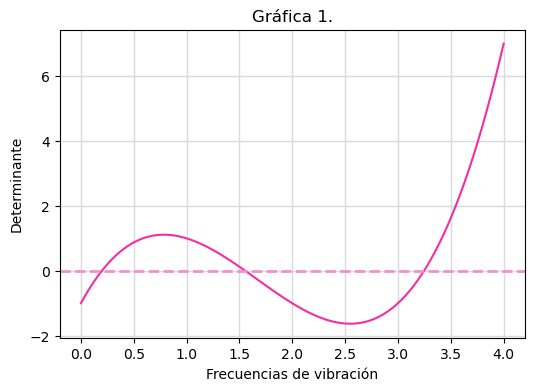

In [8]:
f = lambda x: x**3-5*a*x**2+6*a**2*x-a**3
a =1
X = np.linspace(0,4,100)

plt.figure(figsize=(6,4))
plt.plot(X,f(X), color='#F42EA0')
plt.axhline(color='#EF91CB',linestyle='dashed',linewidth = 2)
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('Frecuencias de vibración')
plt.ylabel('Determinante')
plt.title('Gráfica 1.')

In [9]:
ridders(f,0,0.5)

[0.19806226419516174, 19, 9.5367431640625e-07]

In [10]:
ridders(f,1.25,1.75)

[1.5549581320873713, 19, 9.5367431640625e-07]

In [11]:
ridders(f,3,3.5)

[3.2469796037174676, 19, 9.5367431640625e-07]

Text(0.5, 1.0, 'Gráfica 1.')

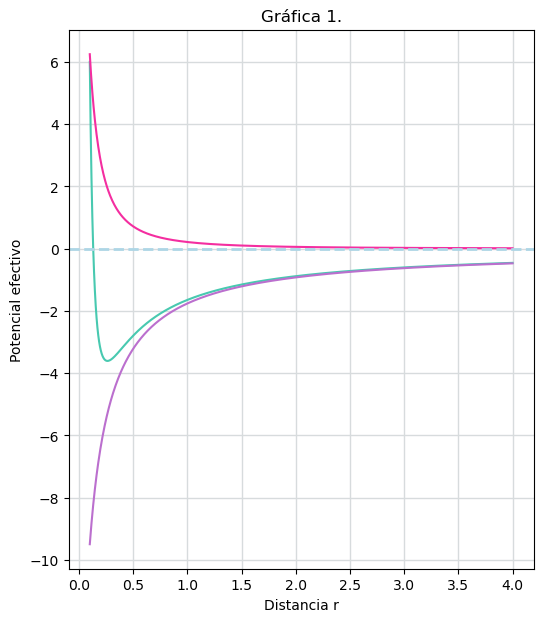

In [12]:
l =0.5
m=0.5
k=1.9
alpha =385
f = lambda r:l**2/(2*m*r**2) - (k/r)*np.exp(-r/alpha)
g = lambda r: l**2/(2*m*r**2)
h = lambda r: - (k/r)*np.exp(-r/alpha)

X = np.linspace(0.1,4,1000)
X2 = np.linspace(0.2,4,1000)

plt.figure(figsize=(6,7))
plt.plot(X,f(X), color='#48C9B0')
plt.plot(X,g(X2),color='#F42EA0')
plt.plot(X,h(X2),color ='#BB6FCE')
plt.axhline(color='#ADD6E6',linestyle='dashed',linewidth = 2)
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('Distancia r')
plt.ylabel('Potencial efectivo')
plt.title('Gráfica 1.')

Text(0.5, 1.0, 'Gráfica 1.')

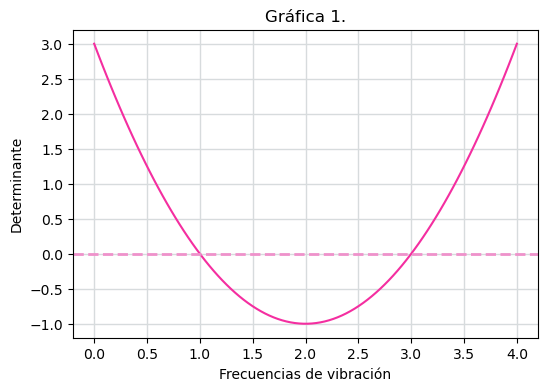

In [15]:
km = 1
d = lambda w: w**2 - 4*km*w + 3*km**2

X = np.linspace(0,4,100)

plt.figure(figsize=(6,4))
plt.plot(X,d(X), color='#F42EA0')
plt.axhline(color='#EF91CB',linestyle='dashed',linewidth = 2)
plt.grid(color = '#D7DBDD',linewidth = 1)
plt.xlabel('Frecuencias de vibración')
plt.ylabel('Determinante')
plt.title('Gráfica 1.')

C:\Users\maryf\AppData\Local\Temp\ipykernel_13912\1336979945.py:12: RuntimeWarning: divide by zero encountered in power
  r2 = lambda x: a*x**-k


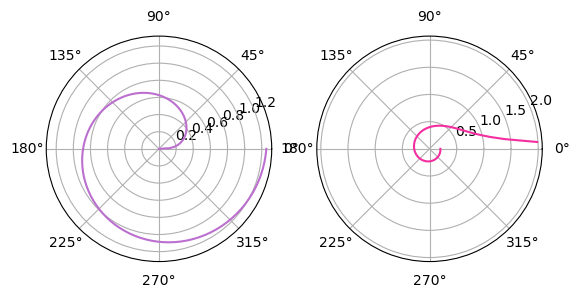

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Definir el rango de ángulos
theta = np.linspace(0, 2*pi, 100)

# Definir la función en coordenadas polares (r(theta))
k = 0.5
a = .5
r1 = lambda x: a*x**k
r2 = lambda x: a*x**-k

# Graficar la función en coordenadas polares

fig,axs = plt.subplots(1, 2, subplot_kw=dict(projection="polar"))
axs[0].plot(theta, r1(theta),color = '#BB6FCE')
axs[1].plot(theta, r2(theta),color = '#F42EA0')

# Personalizar la gráfica
ax.set_title('Gráfica de una función en coordenadas polares')
ax.grid(True)

# Mostrar la gráfica
plt.show()


#### 